# KMeans assignment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler , StandardScaler

### Step 1: Load the data

In [2]:
df = pd.read_csv(r'IRIS.csv')
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [5]:
x = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values
x

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

#### QUESTION
Why does unsupervised learning nor require labeled data?
- This is because unsupervised learning is used to discover patterns and structure not to predict already known answers.


### Step 2 : Visualization

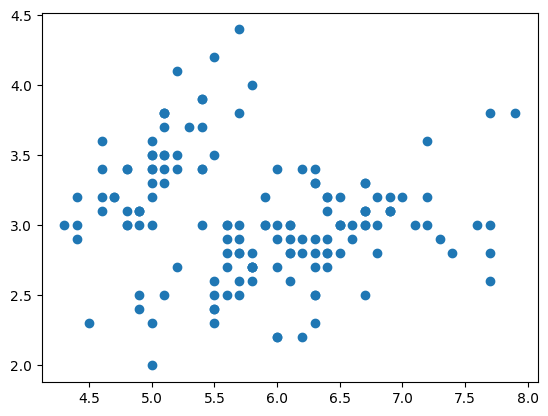

In [6]:
plt.scatter(x[:,0],x[:,1])

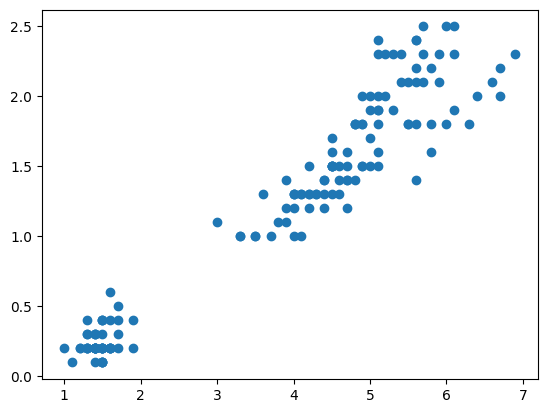

In [7]:
plt.scatter(x[:,2],x[:,3])

#### QUESTION
Which pair of features seem to show natural groupings?
- The petal_width and petal_length seem to show natural groupings

### Step 3: Feature Scaling

In [8]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled

array([[-9.00681170e-01,  1.03205722e+00, -1.34127240e+00,
        -1.31297673e+00],
       [-1.14301691e+00, -1.24957601e-01, -1.34127240e+00,
        -1.31297673e+00],
       [-1.38535265e+00,  3.37848329e-01, -1.39813811e+00,
        -1.31297673e+00],
       [-1.50652052e+00,  1.06445364e-01, -1.28440670e+00,
        -1.31297673e+00],
       [-1.02184904e+00,  1.26346019e+00, -1.34127240e+00,
        -1.31297673e+00],
       [-5.37177559e-01,  1.95766909e+00, -1.17067529e+00,
        -1.05003079e+00],
       [-1.50652052e+00,  8.00654259e-01, -1.34127240e+00,
        -1.18150376e+00],
       [-1.02184904e+00,  8.00654259e-01, -1.28440670e+00,
        -1.31297673e+00],
       [-1.74885626e+00, -3.56360566e-01, -1.34127240e+00,
        -1.31297673e+00],
       [-1.14301691e+00,  1.06445364e-01, -1.28440670e+00,
        -1.44444970e+00],
       [-5.37177559e-01,  1.49486315e+00, -1.28440670e+00,
        -1.31297673e+00],
       [-1.26418478e+00,  8.00654259e-01, -1.22754100e+00,
      

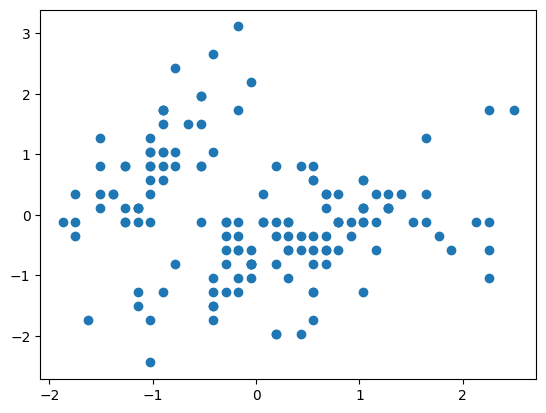

In [9]:
plt.scatter(x_scaled[:,0], x_scaled[:,1])

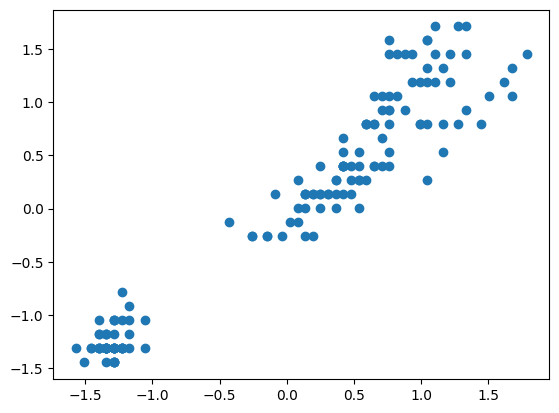

In [10]:
plt.scatter(x_scaled[:,2], x_scaled[:,3])

#### QUESTION
Why is feature scaling important when using K-Means?
- it brings all features into a similar range and reduces the impact of outliers

### Step 4: Apply K-Means clustering

In [11]:
km = KMeans(n_clusters=3)
km

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [12]:
y_pred = km.fit_predict(x_scaled)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 2, 0, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 0,
       2, 2, 2, 2, 0, 2, 2, 2, 2, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0], dtype=int32)

In [13]:
scaler = StandardScaler()
scaler.fit(df[['petal_length','petal_width']])
df[['petal_length','petal_width']] = scaler.transform(df[['petal_length','petal_width']])
df['Cluster'] = y_pred
df.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species,Cluster
0,5.1,3.5,-1.341272,-1.312977,Iris-setosa,1
1,4.9,3.0,-1.341272,-1.312977,Iris-setosa,1
2,4.7,3.2,-1.398138,-1.312977,Iris-setosa,1
3,4.6,3.1,-1.284407,-1.312977,Iris-setosa,1
4,5.0,3.6,-1.341272,-1.312977,Iris-setosa,1
5,5.4,3.9,-1.170675,-1.050031,Iris-setosa,1
6,4.6,3.4,-1.341272,-1.181504,Iris-setosa,1
7,5.0,3.4,-1.284407,-1.312977,Iris-setosa,1
8,4.4,2.9,-1.341272,-1.312977,Iris-setosa,1
9,4.9,3.1,-1.284407,-1.444450,Iris-setosa,1


In [14]:
centroids = km.cluster_centers_
centroids

array([[ 1.03359865,  0.01388418,  0.94369497,  0.97226253],
       [-1.00206653,  0.89510445, -1.30297509, -1.25663117],
       [-0.16840578, -0.97008147,  0.25962078,  0.17609756]])

#### QUESTION
What does a cluster centroid represent in simple form?
- It represents the centre point of a certain group of similar data or a cluster

### Step 5: Cluster Visualization


In [15]:
df1 = df[df.Cluster == 0]
df2 = df[df.Cluster == 1]
df3 = df[df.Cluster == 2]

Text(0.5, 1.0, 'Cluster visualization with centroids')

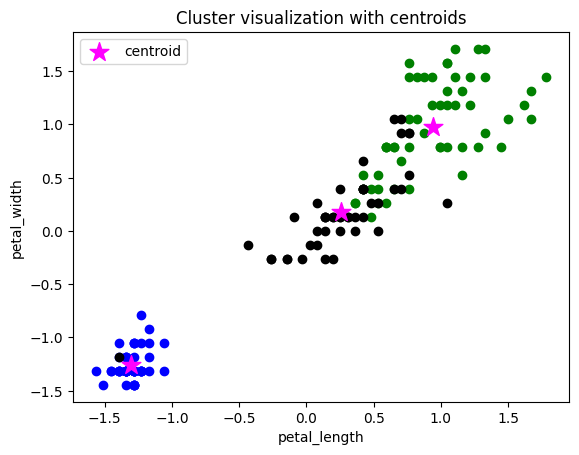

In [16]:
plt.scatter(df1['petal_length'], df1['petal_width'], color='green')
plt.scatter(df2['petal_length'], df2['petal_width'], color='blue')
plt.scatter(df3['petal_length'], df3['petal_width'], color='black')
plt.scatter(km.cluster_centers_[:,2], km.cluster_centers_[:,3], color='magenta', marker='*', label='centroid', s= 200)

plt.ylabel('petal_width')
plt.xlabel('petal_length')
plt.legend()
plt.title('Cluster visualization with centroids')

#### QUESTION
Do clusters appear separately?Explain your observation
- Yes the clusters appear separately ,, there are three different clusters and each cluster has a centroid

### Step 6: Choosing the number of clusters (Elbow Method)

In [17]:
k_range = range(1,10)
sse = []
for k in k_range:
    km = KMeans(n_clusters=k)
    km.fit(df[['petal_length','petal_width']])
    sse.append(km.inertia_)
sse

[300.0000000000001,
 54.14584701344988,
 18.046983891906276,
 12.554097124795966,
 9.191580367383064,
 7.29613187085195,
 6.039384497183692,
 5.976088527962604,
 5.432477348328426]

C:\Users\Sally\AppData\Local\Temp\ipykernel_5444\3346246789.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 1.0, 'Elbow curve')

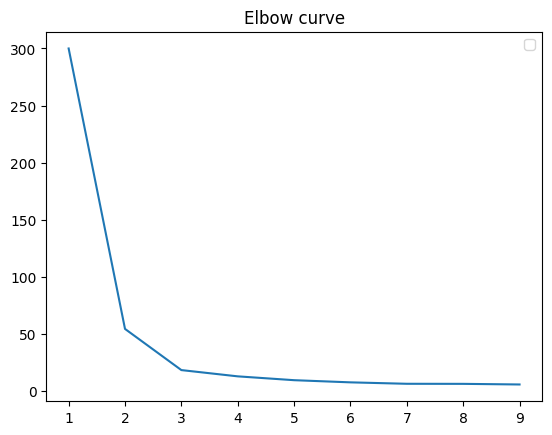

In [18]:
plt.plot(k_range, sse)
plt.legend()
plt.title('Elbow curve')

#### Question
Why is the elbow point a good choice for the number of clusters?
- it gives a balance between accuracy and simplicity.

### Step 7: Interpretation and reflection
What patterns did the clusteing algorithm discover?
- It grouped data points with similar features together. Each cluster represents a group of observations that are more similar to each other than to those in other clusters.

How many clusters seem reasonable based on the plots
- 3 clusters seem reasonable

What challenges did you meet when clustering the data?
- presence of outliers.
